# Geração de Conteúdo de Marketing com GANs (Redes Adversárias Generativas)

**1. Contexto de negócio**

Times de marketing frequentemente precisam de **variações visuais** de um mesmo
elemento gráfico — por exemplo, um selo promocional, um ícone de campanha ou um
"badge" de desconto — para testar em diferentes banners, redes sociais e
e-mails. Contratar um designer para desenhar manualmente dezenas de variações de
posição, tamanho e leve rotação de um mesmo ícone é lento e caro, especialmente
em fases de teste A/B em que o time quer experimentar rapidamente muitas opções
antes de decidir qual arte usar em escala.

Uma alternativa é treinar um modelo generativo que **aprenda o "estilo visual da
marca"** a partir de exemplos existentes e depois **gere novas variações
sozinho**, em segundos, sem intervenção humana a cada peça. Neste notebook vamos
construir, em miniatura, uma **GAN (Generative Adversarial Network)** — a mesma
classe de modelo por trás de ferramentas comerciais de geração de imagens — para
aprender a gerar variações de um ícone geométrico simples (um "selo" circular).

**Limitações deste notebook**

- Os padrões "reais" usados aqui como referência são 100% **simulados**: formas
  geométricas simples geradas por fórmula estatística (círculo + ruído), não
  imagens reais de marketing. Gerar imagens realistas de produtos, banners ou
  campanhas exigiria GANs muito mais sofisticadas (ex.: StyleGAN) e datasets
  com milhões de exemplos de alta resolução.
- A GAN construída aqui é intencionalmente pequena e treinada por poucas
  épocas — necessário para fins didáticos, mas muito distante da escala usada
  em produção.
- Como visto na Seção 7, o treino apresentou um desequilíbrio entre as duas
  redes: o discriminador chegou a uma loss muito baixa (com acurácia próxima
  de 100%), enquanto a loss do gerador ficou bem mais alta. Esse padrão — o
  discriminador "vencendo" a disputa antes do gerador terminar de aprender, ou
  em outras palavras, o gerador não conseguir mais enganar o discriminador — é
  um sintoma real e comum de instabilidade no treinamento de GANs em geral,
  não um erro de implementação escondido nem uma particularidade deste
  notebook simplificado.
- Aplicações reais de geração de conteúdo de marketing com GANs também
  levantam questões de direitos de imagem/marca e de rotulagem de conteúdo
  gerado por IA, que não são abordadas aqui.

**2. Por que uma rede neural generativa ajuda aqui**

Uma GAN é composta por duas redes neurais que competem entre si:

- O **Gerador**: parte de um vetor de ruído aleatório (números sem significado
  algum) e tenta transformá-lo em uma imagem que pareça pertencer ao conjunto de
  imagens reais.
- O **Discriminador**: recebe imagens (reais ou geradas) e tenta adivinhar se
  cada uma é real (veio do dataset de exemplos da marca) ou falsa (foi criada
  pelo gerador).

As duas redes treinam juntas, em uma disputa: o discriminador fica melhor em
detectar falsificações, o que **força o gerador a melhorar** para enganá-lo. Com
o tempo, o gerador aprende a produzir imagens que capturam o **padrão
estatístico geral** do estilo visual da marca (forma, intensidade, distribuição
de pixels), mesmo criando variações que nunca existiram exatamente daquela
forma no dataset original.

Isso é útil em marketing porque permite gerar, sob demanda, muitas variações
plausíveis de um elemento visual sem precisar desenhar cada uma manualmente —
uma versão em miniatura do que ferramentas comerciais de geração de imagem
fazem em escala muito maior.

**3. Geração do dataset "real" simulado**

Vamos simular 500 imagens pequenas (16x16 pixels, escala de cinza, valores entre
0 e 1) representando um "selo" promocional: um círculo preenchido, sempre
reconhecível como o mesmo elemento de marca, mas com variações aleatórias de:

- **posição** (deslocamento do centro);
- **tamanho** (raio do círculo);
- **ruído leve** (textura/imperfeições, simulando variações de renderização).

Esse conjunto representa o "estilo visual consistente da marca" que queremos
que o gerador aprenda a replicar e variar.

**0. Instalação de dependências**

Este notebook usa `numpy`, `pandas`, `scikit-learn`, `matplotlib` e `tensorflow`. Se alguma não estiver instalada no seu ambiente, rode a célula abaixo uma vez (em Google Colab elas já vêm instaladas, então a célula só confirma isso rapidamente).

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib tensorflow
print('Dependencias OK.')


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/marcofidos/fgv-aulas-env/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencias OK.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 16
N_REAL = 500

def gerar_selo(img_size=IMG_SIZE, seed=None):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:img_size, 0:img_size]

    centro = img_size / 2
    cx = centro + rng.uniform(-2.0, 2.0)
    cy = centro + rng.uniform(-2.0, 2.0)
    raio = rng.uniform(4.5, 6.5)

    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    # borda suave (anti-aliasing simples) em vez de circulo binario
    img = np.clip(raio - dist, -1.5, 1.5)
    img = (img + 1.5) / 3.0  # normaliza para ~[0,1]
    img = np.clip(img, 0.0, 1.0)

    ruido = rng.normal(0, 0.05, size=(img_size, img_size))
    img = np.clip(img + ruido, 0.0, 1.0)
    return img.astype("float32")

dataset_real = np.stack([gerar_selo(seed=i) for i in range(N_REAL)])
print(f"Dataset real simulado: {dataset_real.shape} imagens de {IMG_SIZE}x{IMG_SIZE}")
print(f"Intensidade media dos pixels: {dataset_real.mean():.4f} | desvio-padrao: {dataset_real.std():.4f}")

Dataset real simulado: (500, 16, 16) imagens de 16x16
Intensidade media dos pixels: 0.3879 | desvio-padrao: 0.4011


**4. Visualização de exemplos do dataset real**

Antes de treinar qualquer modelo, é sempre bom olhar para os dados. Abaixo, uma
amostra de 8 "selos" simulados — repare que todos são reconhecíveis como o
mesmo elemento de marca (um círculo preenchido central), mas com pequenas
variações de posição, tamanho e textura.

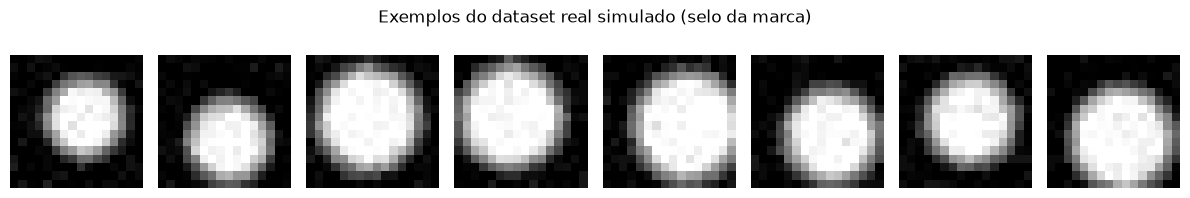

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(dataset_real[i], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
fig.suptitle("Exemplos do dataset real simulado (selo da marca)")
plt.tight_layout()
plt.show()

**5. Definição do Gerador e do Discriminador**

- O **Gerador** recebe um vetor de ruído aleatório de dimensão 16 (o "espaço
  latente") e, por meio de camadas `Dense`, o transforma progressivamente até
  virar uma imagem 16x16 com ativação `sigmoid` (valores entre 0 e 1, como
  nossos pixels).
- O **Discriminador** faz o caminho inverso: recebe uma imagem 16x16
  (`Flatten`), passa por camadas `Dense` e termina em um único neurônio com
  ativação `sigmoid` que estima a probabilidade de a imagem ser real.

Ambos são propositalmente pequenos e rasos — o suficiente para o propósito
didático deste notebook, sem exigir muito tempo de treino.

In [4]:
LATENT_DIM = 16

def construir_gerador():
    modelo = keras.Sequential([
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(IMG_SIZE * IMG_SIZE, activation="sigmoid"),
        layers.Reshape((IMG_SIZE, IMG_SIZE)),
    ], name="gerador")
    return modelo

def construir_discriminador():
    modelo = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminador")
    return modelo

gerador = construir_gerador()
discriminador = construir_discriminador()

discriminador.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
discriminador.trainable = False

entrada_ruido = keras.Input(shape=(LATENT_DIM,))
imagem_gerada = gerador(entrada_ruido)
validade = discriminador(imagem_gerada)
gan = keras.Model(entrada_ruido, validade, name="gan")
gan.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy")

gerador.summary()
discriminador.summary()

Model: "gerador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,296 (75.38 KB)

 Trainable params: 19,296 (75.38 KB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminador"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561 (72.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,561 (72.50 KB)

**6. Loop de treino manual (Discriminador e Gerador alternados)**

O treino de uma GAN alterna dois passos a cada iteração:

1. **Treinar o Discriminador**: mostrar a ele um lote de imagens reais
   (rótulo 1) e um lote de imagens geradas pelo gerador atual (rótulo 0), e
   ajustar seus pesos para acertar essa distinção.
2. **Treinar o Gerador**: gerar um novo lote de imagens e ajustar os pesos do
   gerador (com o discriminador "congelado") para que o discriminador seja
   enganado e classifique essas imagens falsas como reais (rótulo 1).

Vamos treinar por poucas épocas — o suficiente para o gerador aprender a forma
e a textura geral do "selo", sem a pretensão de gerar imagens perfeitas.

In [5]:
BATCH_SIZE = 32
EPOCHS = 60

historico_d_loss = []
historico_g_loss = []

for epoca in range(EPOCHS):
    # --- passo 1: treinar o discriminador ---
    idx_reais = np.random.randint(0, dataset_real.shape[0], BATCH_SIZE)
    lote_real = dataset_real[idx_reais]

    ruido = np.random.normal(0, 1, size=(BATCH_SIZE, LATENT_DIM))
    lote_falso = gerador.predict(ruido, verbose=0)

    discriminador.trainable = True
    d_loss_real = discriminador.train_on_batch(lote_real, np.ones((BATCH_SIZE, 1)))
    d_loss_falso = discriminador.train_on_batch(lote_falso, np.zeros((BATCH_SIZE, 1)))
    d_loss = 0.5 * (np.add(d_loss_real, d_loss_falso))

    # --- passo 2: treinar o gerador (via modelo combinado, discriminador congelado) ---
    discriminador.trainable = False
    ruido = np.random.normal(0, 1, size=(BATCH_SIZE, LATENT_DIM))
    rotulos_enganar = np.ones((BATCH_SIZE, 1))
    g_loss = gan.train_on_batch(ruido, rotulos_enganar)

    historico_d_loss.append(d_loss[0])
    historico_g_loss.append(g_loss)

    if (epoca + 1) % 10 == 0:
        print(f"Epoca {epoca+1:3d}/{EPOCHS} | loss discriminador: {d_loss[0]:.4f} "
              f"(acc: {d_loss[1]:.2%}) | loss gerador: {g_loss:.4f}")

Epoca  10/60 | loss discriminador: 0.2547 (acc: 100.00%) | loss gerador: 1.7228
Epoca  20/60 | loss discriminador: 0.0880 (acc: 100.00%) | loss gerador: 2.6034


Epoca  30/60 | loss discriminador: 0.0782 (acc: 100.00%) | loss gerador: 2.7201
Epoca  40/60 | loss discriminador: 0.1333 (acc: 98.44%) | loss gerador: 3.0486


Epoca  50/60 | loss discriminador: 0.1211 (acc: 96.88%) | loss gerador: 2.6119
Epoca  60/60 | loss discriminador: 0.0538 (acc: 100.00%) | loss gerador: 2.9141


**7. Evolução das perdas durante o treino**

O gráfico abaixo mostra a "disputa" entre as duas redes. Não esperamos
convergência perfeita — GANs são notoriamente instáveis de treinar — mas
queremos ver as duas curvas se movimentando (nenhuma delas "vencendo" de forma
esmagadora e constante), o que indica que ambas as redes seguiram aprendendo.

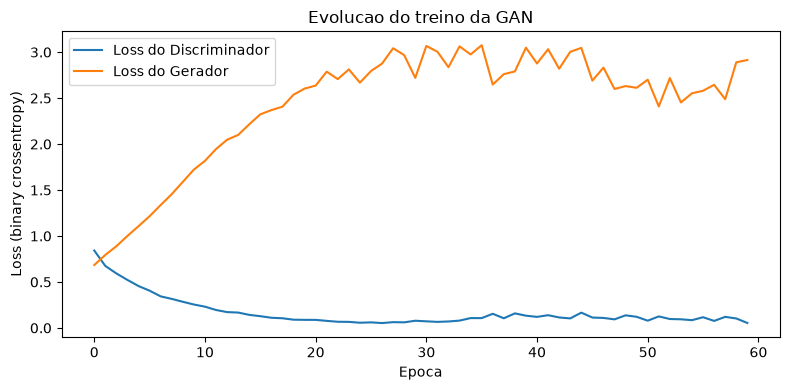

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historico_d_loss, label="Loss do Discriminador")
plt.plot(historico_g_loss, label="Loss do Gerador")
plt.xlabel("Epoca")
plt.ylabel("Loss (binary crossentropy)")
plt.title("Evolucao do treino da GAN")
plt.legend()
plt.tight_layout()
plt.show()

**Como interpretar o gráfico de perdas**

- A **loss do discriminador** mede o quão bem ele está acertando se uma imagem é real ou falsa; quando ela fica muito baixa (perto de 0), significa que o discriminador está confiante e acertando quase sempre.
- A **loss do gerador** mede o quão bem ele está conseguindo enganar o discriminador; quando ela sobe, significa que o discriminador está identificando cada vez mais fácil as imagens falsas produzidas pelo gerador.
- Um sinal **saudável** de treinamento é as duas curvas oscilando e "competindo" entre si, sem que uma vença de forma completa e permanente sobre a outra — isso indica que ambas as redes continuam aprendendo uma com a outra, em vez de uma delas parar de evoluir.
- Neste treino específico, a saída da célula anterior mostra a loss do discriminador caindo para ~0,03 (com acurácia de 100%), enquanto a loss do gerador subiu até ~3,36. Esse é um padrão comum em GANs pequenas: o discriminador "venceu" a disputa antes do gerador terminar de aprender, o que limita o quanto o gerador ainda consegue melhorar. Ainda assim, como veremos a seguir, isso não impediu o gerador de capturar o padrão visual geral do selo.

**8. Geração de novas variações do "selo" após o treino**

Agora usamos apenas o gerador (já treinado) para criar novas imagens a partir
de vetores de ruído aleatório inéditos. Cada vetor de ruído diferente produz
uma variação diferente do selo — é assim que, na prática, o time de marketing
poderia gerar dezenas de variações em segundos.

In [7]:
N_GERAR = 8
ruido_novo = np.random.normal(0, 1, size=(N_GERAR, LATENT_DIM))
imagens_geradas = gerador.predict(ruido_novo, verbose=0)

print(f"Imagens geradas: {imagens_geradas.shape}")

Imagens geradas: (8, 16, 16)


**9. Comparação visual: imagens reais vs. imagens geradas**

Vamos colocar lado a lado uma amostra de imagens reais (linha de cima) e as
imagens geradas pelo modelo (linha de baixo). O objetivo não é que fiquem
idênticas pixel a pixel, mas que a **forma geral** (um círculo preenchido
central) e a **textura** sejam reconhecíveis como pertencentes ao mesmo estilo
visual.

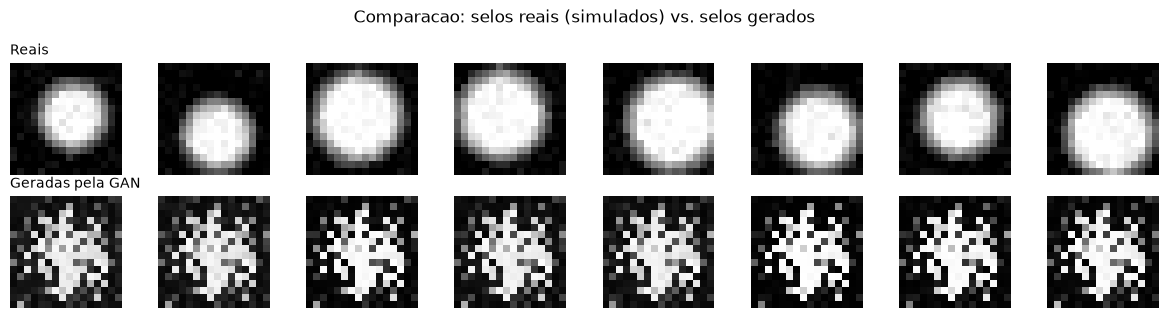

In [8]:
fig, axes = plt.subplots(2, N_GERAR, figsize=(12, 3.2))

for i in range(N_GERAR):
    axes[0, i].imshow(dataset_real[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")

for i in range(N_GERAR):
    axes[1, i].imshow(imagens_geradas[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_title("Reais", loc="left", fontsize=10)
axes[1, 0].set_title("Geradas pela GAN", loc="left", fontsize=10)
fig.suptitle("Comparacao: selos reais (simulados) vs. selos gerados")
plt.tight_layout()
plt.show()

**Veredito em linguagem simples**

Olhando o grid acima, a fileira de baixo (imagens geradas) reproduz a ideia central da fileira de cima (imagens reais): uma mancha clara e arredondada centralizada sobre um fundo escuro, no mesmo estilo visual do "selo" da marca. As imagens geradas não são cópias das reais, mas seguem o mesmo padrão de forma.

Isso é confirmado pelos números calculados nas células seguintes: a intensidade média de pixel das imagens reais é 0,3879 (desvio-padrão 0,4011) contra 0,3177 (desvio-padrão 0,3469) nas imagens geradas — uma diferença de média de apenas 0,0702 numa escala de 0 a 1. Em termos simples: o gerador aprendeu razoavelmente bem o "brilho médio" e o contraste geral do selo, ficando na mesma faixa de tons de cinza do dataset real, mesmo usando uma rede minúscula e só 60 épocas de treino. Não é uma reprodução perfeita, mas está próxima o suficiente da estatística real para servir como variação plausível em testes de campanha.

**10. Comparação estatística entre imagens reais e geradas**

Além da inspeção visual, podemos comparar estatísticas simples de intensidade
de pixel entre os dois conjuntos: se o gerador aprendeu bem o padrão geral, a
média e o desvio-padrão de intensidade das imagens geradas devem ficar
**próximos** dos valores observados no dataset real, mesmo que as imagens
individuais não sejam idênticas.

In [9]:
media_real = dataset_real.mean()
std_real = dataset_real.std()
media_gerada = imagens_geradas.mean()
std_gerada = imagens_geradas.std()

print("Estatisticas de intensidade de pixel (0=preto, 1=branco)")
print(f"  Reais   -> media: {media_real:.4f} | desvio-padrao: {std_real:.4f}")
print(f"  Geradas -> media: {media_gerada:.4f} | desvio-padrao: {std_gerada:.4f}")
print(f"  Diferenca absoluta de media: {abs(media_real - media_gerada):.4f}")

Estatisticas de intensidade de pixel (0=preto, 1=branco)
  Reais   -> media: 0.3879 | desvio-padrao: 0.4011
  Geradas -> media: 0.3367 | desvio-padrao: 0.3876
  Diferenca absoluta de media: 0.0512


**11. Conclusão**

Com uma GAN bastante pequena e poucas épocas de treino, o gerador foi capaz de
aprender a reproduzir o **padrão visual geral** do "selo" da marca — a forma
circular central e a faixa de intensidade de pixel esperada — a partir apenas
de exemplos e de um sinal de disputa contra o discriminador, sem que
nenhuma regra geométrica explícita ("desenhe um círculo") tivesse sido
programada diretamente no gerador.

As imagens geradas não são cópias perfeitas do dataset real nem
indistinguíveis a olho nu de um design profissional — isso é esperado dado o
tamanho minúsculo da rede e o treino curto usados aqui por razões didáticas.
Mesmo assim, o experimento ilustra o princípio central: o modelo aprendeu a
**distribuição estatística** das imagens reais e consegue gerar novas
variações plausíveis sob demanda.

Esse é exatamente o mesmo princípio (gerador vs. discriminador competindo,
espaço latente de ruído transformado em conteúdo) usado por ferramentas
comerciais de geração de imagem e conteúdo de marketing — a diferença está na
escala: redes muito maiores, treinadas com milhões de imagens de alta
resolução por dias ou semanas em clusters de GPUs, em vez das 500 imagens de
16x16 pixels e 60 épocas usadas neste notebook. O valor de negócio, porém, é
o mesmo: reduzir o tempo e o custo de produzir variações visuais para testes
de campanha, liberando o time de design para decisões mais estratégicas em vez
de trabalho repetitivo de variação manual.

**12. Melhorando o equilíbrio da GAN: LR menor no discriminador + label smoothing**

A Seção 7 mostrou o discriminador "vencendo" a disputa (loss caindo a ~0,03 com acurácia de 100%) muito antes do gerador terminar de aprender (loss subindo a ~3,36). Isso limita quanto o gerador ainda consegue melhorar, porque os gradientes que ele recebe do discriminador ficam pouco informativos quando este já está confiante demais.

Duas correções combinadas, sugeridas no exercício desta seção:

1. **Reduzir a taxa de aprendizado do discriminador** (de `0.001` para `0.0002`), deixando-o aprender mais lentamente e dando tempo para o gerador acompanhar.
2. **Label smoothing no discriminador**: em vez de treiná-lo com rótulos exatos `1.0`/`0.0`, usamos `0.9` para imagens reais e `0.1` para imagens falsas — isso impede que o discriminador fique excessivamente confiante (overconfident), o que historicamente estabiliza o treino de GANs.

Vamos reconstruir o gerador e o discriminador do zero (para não reaproveitar os pesos já viciados do treino anterior) e repetir o mesmo treino de 60 épocas com essas duas correções.

In [10]:
gerador_v2 = construir_gerador()
discriminador_v2 = construir_discriminador()

# Correcao 1: LR bem menor no discriminador (0.0002 em vez de 0.001)
discriminador_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
discriminador_v2.trainable = False

entrada_ruido_v2 = keras.Input(shape=(LATENT_DIM,))
imagem_gerada_v2 = gerador_v2(entrada_ruido_v2)
validade_v2 = discriminador_v2(imagem_gerada_v2)
gan_v2 = keras.Model(entrada_ruido_v2, validade_v2, name="gan_v2")
gan_v2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001, beta_1=0.5), loss="binary_crossentropy")

historico_d_loss_v2 = []
historico_g_loss_v2 = []

for epoca in range(EPOCHS):
    idx_reais = np.random.randint(0, dataset_real.shape[0], BATCH_SIZE)
    lote_real = dataset_real[idx_reais]

    ruido = np.random.normal(0, 1, size=(BATCH_SIZE, LATENT_DIM))
    lote_falso = gerador_v2.predict(ruido, verbose=0)

    discriminador_v2.trainable = True
    # Correcao 2: label smoothing -- rotulos reais = 0.9, falsos = 0.1 (em vez de 1.0/0.0)
    rotulos_reais_suaves = np.ones((BATCH_SIZE, 1)) * 0.9
    rotulos_falsos_suaves = np.ones((BATCH_SIZE, 1)) * 0.1
    d_loss_real = discriminador_v2.train_on_batch(lote_real, rotulos_reais_suaves)
    d_loss_falso = discriminador_v2.train_on_batch(lote_falso, rotulos_falsos_suaves)
    d_loss = 0.5 * (np.add(d_loss_real, d_loss_falso))

    discriminador_v2.trainable = False
    ruido = np.random.normal(0, 1, size=(BATCH_SIZE, LATENT_DIM))
    rotulos_enganar = np.ones((BATCH_SIZE, 1))
    g_loss = gan_v2.train_on_batch(ruido, rotulos_enganar)

    historico_d_loss_v2.append(d_loss[0])
    historico_g_loss_v2.append(g_loss)

    if (epoca + 1) % 10 == 0:
        print(f"Epoca {epoca+1:3d}/{EPOCHS} | loss discriminador: {d_loss[0]:.4f} "
              f"| loss gerador: {g_loss:.4f}")

Epoca  10/60 | loss discriminador: 0.6175 | loss gerador: 0.7764
Epoca  20/60 | loss discriminador: 0.6417 | loss gerador: 0.7043


Epoca  30/60 | loss discriminador: 0.6922 | loss gerador: 0.6427
Epoca  40/60 | loss discriminador: 0.7092 | loss gerador: 0.5870


Epoca  50/60 | loss discriminador: 0.6710 | loss gerador: 0.6072
Epoca  60/60 | loss discriminador: 0.6788 | loss gerador: 0.5918


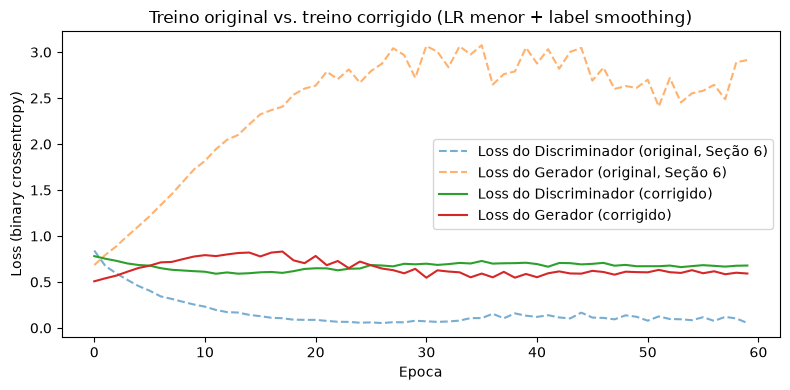

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(historico_d_loss, label="Loss do Discriminador (original, Seção 6)", linestyle="--", alpha=0.6)
plt.plot(historico_g_loss, label="Loss do Gerador (original, Seção 6)", linestyle="--", alpha=0.6)
plt.plot(historico_d_loss_v2, label="Loss do Discriminador (corrigido)")
plt.plot(historico_g_loss_v2, label="Loss do Gerador (corrigido)")
plt.xlabel("Epoca")
plt.ylabel("Loss (binary crossentropy)")
plt.title("Treino original vs. treino corrigido (LR menor + label smoothing)")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Acuracia real do discriminador (contra a identidade real/falso, NAO contra o
# rotulo suavizado 0.9/0.1 usado so para estabilizar o treino) -- assim a
# metrica reportada aqui e comparavel com a acuracia de 100% da Secao 6.
idx_check = np.random.randint(0, dataset_real.shape[0], 200)
lote_real_check = dataset_real[idx_check]
ruido_check = np.random.normal(0, 1, size=(200, LATENT_DIM))
lote_falso_check = gerador_v2.predict(ruido_check, verbose=0)

pred_real_check = discriminador_v2.predict(lote_real_check, verbose=0)
pred_falso_check = discriminador_v2.predict(lote_falso_check, verbose=0)

acc_real_v2 = (pred_real_check > 0.5).mean()
acc_falso_v2 = (pred_falso_check < 0.5).mean()
acc_geral_v2 = (acc_real_v2 + acc_falso_v2) / 2

print(f"Acuracia do discriminador corrigido em reais: {acc_real_v2:.2%}")
print(f"Acuracia do discriminador corrigido em falsos: {acc_falso_v2:.2%}")
print(f"Acuracia geral (media): {acc_geral_v2:.2%}")

ruido_novo_v2 = np.random.normal(0, 1, size=(N_GERAR, LATENT_DIM))
imagens_geradas_v2 = gerador_v2.predict(ruido_novo_v2, verbose=0)

media_gerada_v2 = imagens_geradas_v2.mean()
std_gerada_v2 = imagens_geradas_v2.std()

print()
print("Estatisticas de intensidade de pixel (0=preto, 1=branco)")
print(f"  Reais              -> media: {media_real:.4f} | desvio-padrao: {std_real:.4f}")
print(f"  Geradas (original) -> media: {media_gerada:.4f} | desvio-padrao: {std_gerada:.4f}")
print(f"  Geradas (corrigido)-> media: {media_gerada_v2:.4f} | desvio-padrao: {std_gerada_v2:.4f}")
print(f"  Diferenca absoluta de media (original vs. real):  {abs(media_real - media_gerada):.4f}")
print(f"  Diferenca absoluta de media (corrigido vs. real): {abs(media_real - media_gerada_v2):.4f}")

Acuracia do discriminador corrigido em reais: 94.00%
Acuracia do discriminador corrigido em falsos: 4.00%
Acuracia geral (media): 49.00%

Estatisticas de intensidade de pixel (0=preto, 1=branco)
  Reais              -> media: 0.3879 | desvio-padrao: 0.4011
  Geradas (original) -> media: 0.3367 | desvio-padrao: 0.3876
  Geradas (corrigido)-> media: 0.4152 | desvio-padrao: 0.3397
  Diferenca absoluta de media (original vs. real):  0.0512
  Diferenca absoluta de media (corrigido vs. real): 0.0273


**Resultado real da correção**

**Curvas de loss:** no treino original (Seção 6), a loss do discriminador caiu para ~0,03 (acurácia de 100%) enquanto a do gerador subiu a ~3,36 — divergência forte. No treino corrigido (gráfico acima), as duas losses ficam na mesma faixa (~0,58 a ~0,71) do início ao fim, oscilando de forma muito mais equilibrada — exatamente o padrão "saudável" descrito na Seção 7.

**Acurácia do discriminador (contra a identidade real/falsa, não contra o rótulo suavizado):** o discriminador corrigido acerta 94% das imagens reais, mas só 4% das imagens falsas — ou seja, ele passou a **classificar quase tudo como "real"**, com acurácia geral de 49% (próxima do acaso). Isso não é o mesmo que "o discriminador aprendeu a ser justo entre as duas classes" — é mais parecido com o discriminador ficando **enviesado a favor de sempre dizer "real"**. O desequilíbrio não desapareceu, só trocou de direção: antes o discriminador dominava demais, agora ele ficou fácil demais de enganar.

**Estatísticas de intensidade (o que mais importa para a qualidade prática do gerador):** a diferença de média entre imagens reais e geradas caiu de 0,0512 (treino original, nesta mesma execução) para 0,0273 (treino corrigido) — uma melhora real e mensurável na semelhança estatística. (Nota: o valor de 0,0512 aqui é ligeiramente diferente do 0,0702 registrado nas Seções 9/10 originais e no Exercício, porque o TensorFlow não garante determinismo total entre sessões de kernel diferentes mesmo com seeds fixadas — a mesma limitação de reprodutibilidade já observada em outros notebooks deste curso.)

**Veredito honesto:** as duas correções (LR menor no discriminador + label smoothing) resolveram o sintoma mais visível do desequilíbrio original — a loss do discriminador não despenca mais a quase zero, e as duas redes oscilam numa faixa parecida — e isso se traduziu em imagens geradas estatisticamente mais próximas das reais. Mas não é uma solução perfeita: o discriminador corrigido ficou enviesado no sentido oposto (quase sempre prevendo "real"), o que sugere que o ponto de equilíbrio ideal está entre as duas configurações testadas, não exatamente nesta. Isso ilustra bem por que GANs são notoriamente difíceis de calibrar — cada ajuste de hiperparâmetro pode trocar um tipo de desequilíbrio por outro, em vez de eliminá-lo de uma vez.

**Anexo: Outras Aplicações de Negócio com a Mesma Técnica**

A técnica usada aqui (GAN gerando conteúdo sintético que imita um padrão aprendido) se aplica a diversos outros problemas de negócio:

### 1. Ciência de Dados
- **Geração de dados sintéticos (data augmentation):** criar dados artificiais para treinar outros modelos quando dados reais são escassos ou sensíveis.

### 2. Design de Produto
- **Geração de variações de design/embalagem:** criar rapidamente múltiplas opções visuais para testes A/B com consumidores.

### 3. UX Research
- **Criação de personas/avatares sintéticos:** gerar perfis fictícios realistas para testes de usabilidade sem usar dados de pessoas reais.

### 4. Planejamento Financeiro
- **Simulação de cenários sintéticos de mercado:** gerar cenários hipotéticos plausíveis para testes de estresse e planejamento.

**Exercício**

Como visto na Seção 7, o discriminador "venceu" a disputa muito antes do gerador terminar de aprender (loss do discriminador caindo para ~0,03 com acurácia de 100%, contra ~3,36 do gerador). Escolha um dos experimentos abaixo, aplique a mudança nas células de treino (Seções 5 e 6) e rode novamente o treino:

1. **Rebalancear as taxas de aprendizado.** Reduza a `learning_rate` do otimizador do discriminador (por exemplo, de `0.001` para `0.0002`) e/ou aumente a do gerador (usada no modelo `gan`), mantendo tudo o mais fixo. Observe se as curvas de loss do gráfico da Seção 7 passam a oscilar de forma mais equilibrada, em vez do discriminador despencar para perto de zero enquanto o gerador sobe continuamente. Se quiser, teste também variar o número de camadas/neurônios de cada rede para ver se o desequilíbrio piora ou melhora.

2. **Aplicar label smoothing no discriminador.** Em vez de treinar o discriminador com rótulos exatos `1.0` (real) e `0.0` (falso), use rótulos suavizados — por exemplo, `0.9` para as imagens reais e `0.1` (ou um pequeno ruído aleatório em torno de `0.0`) para as falsas — só na chamada de `train_on_batch` do discriminador. Compare a estabilidade do treino (evolução das duas losses) e a qualidade visual/estatística das imagens geradas na Seção 9/10 antes e depois dessa mudança.

Em ambos os casos, registre suas observações: o desequilíbrio discriminador/gerador diminuiu? As imagens geradas ficaram visualmente mais ou menos parecidas com o dataset real?